# Project Update 2

# POS-tag frequencies and dependency tree depths shift from Human (T0) to AI (T3)

## Analyze data as base+ iteration

In [1]:
import re
import pandas as pd
from pathlib import Path

def parse_version(version: str):
    v = str(version).strip().lower()

    if v in ["original", "orignal"]:
        return {"base": "original", "iteration": 0}

    candidates = [
        "chatgpt",
        "palm",
        "dipper(high)",
        "dipper(low)",
        "pegasus(slight)",
        "pegasus(full)",
    ]

    for token in candidates:
        if v == token:
            return {"base": token, "iteration": 1}

        parts = v.split("_")
        if all(p == token for p in parts):
            return {"base": token, "iteration": len(parts)}

    return {"base": "other", "iteration": None}

In [2]:
ROOT = Path("..").resolve()
RAW_DIR = ROOT / "data" / "raw" / "paraphrased_datasets"
OUT_DIR = ROOT / "experiments" / "stylometry_results"
OUT_DIR.mkdir(parents=True, exist_ok=True)

files = sorted(RAW_DIR.glob("*_paraphrased.csv"))

dfs = []
for f in files:
    df = pd.read_csv(f)
    df["dataset"] = f.name.replace("_paraphrased.csv", "")
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
df_all.columns = [c.strip().lower() for c in df_all.columns]

if "version" not in df_all.columns and "version_name" in df_all.columns:
    df_all = df_all.rename(columns={"version_name": "version"})

In [3]:
parsed = df_all["version"].apply(parse_version).apply(pd.Series)
df_all = pd.concat([df_all, parsed], axis=1)

df_all[["version", "base", "iteration"]].drop_duplicates().sort_values(["base", "iteration"]).head(50)

,version,base,iteration
1626,chatgpt,chatgpt,1.0
13457,chatgpt_chatgpt,chatgpt,2.0
14816,chatgpt_chatgpt_chatgpt,chatgpt,3.0
30527,dipper(high),dipper(high),1.0
32153,dipper(high)_dipper(high),dipper(high),2.0
33779,dipper(high)_dipper(high)_dipper(high),dipper(high),3.0
25649,dipper(low),dipper(low),1.0
27275,dipper(low)_dipper(low),dipper(low),2.0
28901,dipper(low)_dipper(low)_dipper(low),dipper(low),3.0
0,original,original,0.0


## Wide chain for paraphraser T0/T1/T2/T3

In [4]:
def build_chain_paired(df, base_token):
    tmp = df.copy()

    keep = (
        (tmp["base"] == "original") |
        (tmp["base"] == base_token)
    )
    tmp = tmp[keep].copy()

    tmp["stage"] = tmp["iteration"].map({
        0: "T0",
        1: "T1",
        2: "T2",
        3: "T3"
    })

    tmp = tmp[tmp["stage"].notna()].copy()

    paired = (
        tmp.pivot_table(
            index=["dataset", "key", "source"],
            columns="stage",
            values="text",
            aggfunc="first"
        )
        .reset_index()
    )

    expected = ["dataset", "key", "source", "T0", "T1", "T2", "T3"]
    for col in expected:
        if col not in paired.columns:
            paired[col] = pd.NA

    paired = paired[expected].dropna(subset=["T0", "T1", "T2", "T3"]).copy()
    return paired

In [5]:
chains = {}

for base in [
    "chatgpt",
    "palm",
    "dipper(high)",
    "dipper(low)",
    "pegasus(slight)",
    "pegasus(full)"
]:
    chains[base] = build_chain_paired(df_all, base)
    print(base, chains[base].shape)

chatgpt (19049, 7)
palm (16924, 7)
dipper(high) (19342, 7)
dipper(low) (19342, 7)
pegasus(slight) (19342, 7)
pegasus(full) (19328, 7)


## spaCy POS batch

In [16]:
import spacy
import numpy as np

nlp_pos = spacy.load("en_core_web_sm", disable=["ner","parser"])

ALL_POS = [
    "ADJ", "ADP", "ADV", "AUX", "CCONJ", "DET", "INTJ", "NOUN",
    "NUM", "PART", "PRON", "PROPN", "PUNCT", "SCONJ", "SYM", "VERB", "X"
]

def extract_pos_batch(texts, batch_size=128):
    texts = [str(t) if pd.notna(t) else "" for t in texts]
    out = []

    for i, doc in enumerate(nlp_pos.pipe(texts, batch_size=batch_size), start=1):
        counts = {pos: 0 for pos in ALL_POS}
        total = 0

        for token in doc:
            if not token.is_space:
                if token.pos_ in counts:
                    counts[token.pos_] += 1
                total += 1

        if total == 0:
            out.append({pos: 0.0 for pos in ALL_POS})
        else:
            out.append({pos: counts[pos] / total for pos in ALL_POS})

        if i % 1000 == 0:
            print(f"processed {i}/{len(texts)}")

    return out

def dict_to_vector(d, pos_list=ALL_POS):
    return np.array([d.get(p, 0.0) for p in pos_list], dtype=float)

def cosine_similarity(a, b):
    if np.linalg.norm(a) == 0 or np.linalg.norm(b) == 0:
        return np.nan
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

def cosine_col(df, col_a, col_b):
    vals = []
    for _, row in df.iterrows():
        v1 = dict_to_vector(row[col_a])
        v2 = dict_to_vector(row[col_b])
        vals.append(cosine_similarity(v1, v2))
    return vals

In [17]:
for base, df_chain in chains.items():
    print(f"=== POS for {base} ===")

    df_chain["pos_T0"] = extract_pos_batch(df_chain["T0"])
    df_chain.to_pickle(OUT_DIR / f"{base}_pos_step1.pkl")

    df_chain["pos_T1"] = extract_pos_batch(df_chain["T1"])
    df_chain.to_pickle(OUT_DIR / f"{base}_pos_step2.pkl")

    df_chain["pos_T2"] = extract_pos_batch(df_chain["T2"])
    df_chain.to_pickle(OUT_DIR / f"{base}_pos_step3.pkl")

    df_chain["pos_T3"] = extract_pos_batch(df_chain["T3"])
    df_chain.to_pickle(OUT_DIR / f"{base}_pos_final.pkl")

    df_chain["cos_T1"] = cosine_col(df_chain, "pos_T0", "pos_T1")
    df_chain["cos_T2"] = cosine_col(df_chain, "pos_T0", "pos_T2")
    df_chain["cos_T3"] = cosine_col(df_chain, "pos_T0", "pos_T3")

    df_chain.to_pickle(OUT_DIR / f"{base}_trajectory_pos.pkl")
    chains[base] = df_chain

=== POS for chatgpt ===
processed 1000/19049
processed 2000/19049
processed 3000/19049
processed 4000/19049
processed 5000/19049
processed 6000/19049
processed 7000/19049
processed 8000/19049
processed 9000/19049
processed 10000/19049
processed 11000/19049
processed 12000/19049
processed 13000/19049
processed 14000/19049
processed 15000/19049
processed 16000/19049
processed 17000/19049
processed 18000/19049
processed 19000/19049
processed 1000/19049
processed 2000/19049
processed 3000/19049
processed 4000/19049
processed 5000/19049
processed 6000/19049
processed 7000/19049
processed 8000/19049
processed 9000/19049
processed 10000/19049
processed 11000/19049
processed 12000/19049
processed 13000/19049
processed 14000/19049
processed 15000/19049
processed 16000/19049
processed 17000/19049
processed 18000/19049
processed 19000/19049
processed 1000/19049
processed 2000/19049
processed 3000/19049
processed 4000/19049
processed 5000/19049
processed 6000/19049
processed 7000/19049
processed 8

In [18]:
#Fix Cosine Similarity Calculation for Empty Vectors
# === FIX COSINE 
for base in chains.keys():
    print(f"=== computing cosine for {base} ===")

    df_chain = chains[base]

    df_chain["cos_T1"] = cosine_col(df_chain, "pos_T0", "pos_T1")
    df_chain["cos_T2"] = cosine_col(df_chain, "pos_T0", "pos_T2")
    df_chain["cos_T3"] = cosine_col(df_chain, "pos_T0", "pos_T3")

    chains[base] = df_chain

=== computing cosine for chatgpt ===
=== computing cosine for palm ===
=== computing cosine for dipper(high) ===
=== computing cosine for dipper(low) ===
=== computing cosine for pegasus(slight) ===
=== computing cosine for pegasus(full) ===


## Dependency tree depth

In [8]:
nlp_dep = spacy.load("en_core_web_sm", disable=["ner", "tagger", "lemmatizer", "attribute_ruler"])

def dependency_depth_batch(texts, batch_size=64):
    texts = [str(t) if pd.notna(t) else "" for t in texts]
    out = []

    for i, doc in enumerate(nlp_dep.pipe(texts, batch_size=batch_size), start=1):
        depths = []
        for token in doc:
            depth = 0
            t = token
            while t.head != t:
                depth += 1
                t = t.head
            depths.append(depth)

        out.append(np.mean(depths) if depths else 0.0)

        if i % 1000 == 0:
            print(f"DEP processed {i}/{len(texts)}")

    return out

In [9]:
for base, df_chain in chains.items():
    print(f"=== DEP for {base} ===")

    df_chain["dep_T0"] = dependency_depth_batch(df_chain["T0"])
    df_chain["dep_T1"] = dependency_depth_batch(df_chain["T1"])
    df_chain["dep_T2"] = dependency_depth_batch(df_chain["T2"])
    df_chain["dep_T3"] = dependency_depth_batch(df_chain["T3"])

    df_chain.to_pickle(OUT_DIR / f"{base}_dep.pkl")

=== DEP for chatgpt ===
DEP processed 1000/19049
DEP processed 2000/19049
DEP processed 3000/19049
DEP processed 4000/19049
DEP processed 5000/19049
DEP processed 6000/19049
DEP processed 7000/19049
DEP processed 8000/19049
DEP processed 9000/19049
DEP processed 10000/19049
DEP processed 11000/19049
DEP processed 12000/19049
DEP processed 13000/19049
DEP processed 14000/19049
DEP processed 15000/19049
DEP processed 16000/19049
DEP processed 17000/19049
DEP processed 18000/19049
DEP processed 19000/19049
DEP processed 1000/19049
DEP processed 2000/19049
DEP processed 3000/19049
DEP processed 4000/19049
DEP processed 5000/19049
DEP processed 6000/19049
DEP processed 7000/19049
DEP processed 8000/19049
DEP processed 9000/19049
DEP processed 10000/19049
DEP processed 11000/19049
DEP processed 12000/19049
DEP processed 13000/19049
DEP processed 14000/19049
DEP processed 15000/19049
DEP processed 16000/19049
DEP processed 17000/19049
DEP processed 18000/19049
DEP processed 19000/19049
DEP pr

In [19]:
for base, df_chain in chains.items():
    print(base, df_chain[["cos_T1","cos_T2","cos_T3"]].head())

chatgpt stage    cos_T1    cos_T2    cos_T3
0      0.996395  0.994599  0.994704
1      0.961065  0.946800  0.955528
3      0.989115  0.986060  0.982524
4      0.973857  0.977762  0.980771
5      0.972427  0.963157  0.974036
palm stage    cos_T1    cos_T2    cos_T3
0      0.924924  0.938387  0.937689
1      0.976876  0.974840  0.960771
2      0.957310  0.935432  0.933521
3      0.988570  0.984274  0.990024
4      0.904312  0.907067  0.900834
dipper(high) stage    cos_T1    cos_T2    cos_T3
0      0.906299  0.894986  0.937540
1      0.919386  0.866690  0.891996
2      0.947112  0.973463  0.963406
3      0.941154  0.921701  0.939656
4      0.817612  0.767389  0.654777
dipper(low) stage    cos_T1    cos_T2    cos_T3
0      0.981733  0.965552  0.973384
1      0.914107  0.896667  0.871127
2      0.997791  0.995507  0.994387
3      0.991425  0.986321  0.986160
4      0.987976  0.991466  0.988648
pegasus(slight) stage    cos_T1    cos_T2    cos_T3
0      0.999621  0.998005  0.996965
1      0.9

# Trajectory Summary

In [20]:
for base in chains.keys():
    df_chain = chains[base]
    print("\n====", base, "====")
    print(df_chain[["pos_T0", "pos_T1", "pos_T2", "pos_T3"]].head(2))


==== chatgpt ====
stage                                             pos_T0  \
0      {'ADJ': 0.07157676348547717, 'ADP': 0.08298755...   
1      {'ADJ': 0.06707317073170732, 'ADP': 0.10975609...   

stage                                             pos_T1  \
0      {'ADJ': 0.07933194154488518, 'ADP': 0.07933194...   
1      {'ADJ': 0.06818181818181818, 'ADP': 0.10227272...   

stage                                             pos_T2  \
0      {'ADJ': 0.08290155440414508, 'ADP': 0.08497409...   
1      {'ADJ': 0.0755813953488372, 'ADP': 0.087209302...   

stage                                             pos_T3  
0      {'ADJ': 0.08403361344537816, 'ADP': 0.08193277...  
1      {'ADJ': 0.08588957055214724, 'ADP': 0.08588957...  

==== palm ====
stage                                             pos_T0  \
0      {'ADJ': 0.07157676348547717, 'ADP': 0.08298755...   
1      {'ADJ': 0.06707317073170732, 'ADP': 0.10975609...   

stage                                             pos_T1  \
0   

In [25]:
summary_rows = []

for base, df_chain in chains.items():
    summary_rows.append({
        "paraphraser": base,
        "T1_cos": np.nanmean(df_chain["cos_T1"]),
        "T2_cos": np.nanmean(df_chain["cos_T2"]),
        "T3_cos": np.nanmean(df_chain["cos_T3"]),
        "T0_dep": np.nanmean(df_chain["dep_T0"]),
        "T3_dep": np.nanmean(df_chain["dep_T3"]),
    })

trajectory_summary = pd.DataFrame(summary_rows)
trajectory_summary

,paraphraser,T1_cos,T2_cos,T3_cos,T0_dep,T3_dep
0,chatgpt,0.967802,0.963971,0.960951,2.861912,2.856122
1,palm,0.975056,0.969078,0.966348,2.841112,2.796071
2,dipper(high),0.880357,0.855216,0.829851,2.861471,2.574800
3,dipper(low),0.984107,0.978242,0.974107,2.861471,2.942630
4,pegasus(slight),0.992285,0.985559,0.979591,2.861471,2.721915
5,pegasus(full),0.962034,0.945547,0.935639,2.861522,2.483352


# T-SNE

In [26]:
from sklearn.manifold import TSNE
import numpy as np

X = []
labels = []
stages = []

for base, df_chain in chains.items():
    for stage_name in ["pos_T0", "pos_T1", "pos_T2", "pos_T3"]:
        for vec in df_chain[stage_name].dropna():
            X.append(dict_to_vector(vec, ALL_POS))
            labels.append(base)
            stages.append(stage_name)

X = np.array(X)

In [28]:
np.save(OUT_DIR / "tsne_input.npy", X)

In [29]:
from sklearn.manifold import TSNE
import numpy as np
import pickle

print("Starting t-SNE...")

tsne = TSNE(n_components=2, random_state=42, perplexity=30)

X_embedded = tsne.fit_transform(X)

print("t-SNE finished, saving...")

# 保存 embedding
np.save(OUT_DIR / "tsne_embedding.npy", X_embedded)

# 保存 labels（方便画图）
with open(OUT_DIR / "tsne_labels.pkl", "wb") as f:
    pickle.dump({
        "labels": labels,
        "stages": stages
    }, f)

print("Saved successfully.")

Starting t-SNE...
t-SNE finished, saving...
Saved successfully.


In [30]:
X_embedded = np.load(OUT_DIR / "tsne_embedding.npy")

import pickle
with open(OUT_DIR / "tsne_labels.pkl", "rb") as f:
    meta = pickle.load(f)

labels = meta["labels"]
stages = meta["stages"]

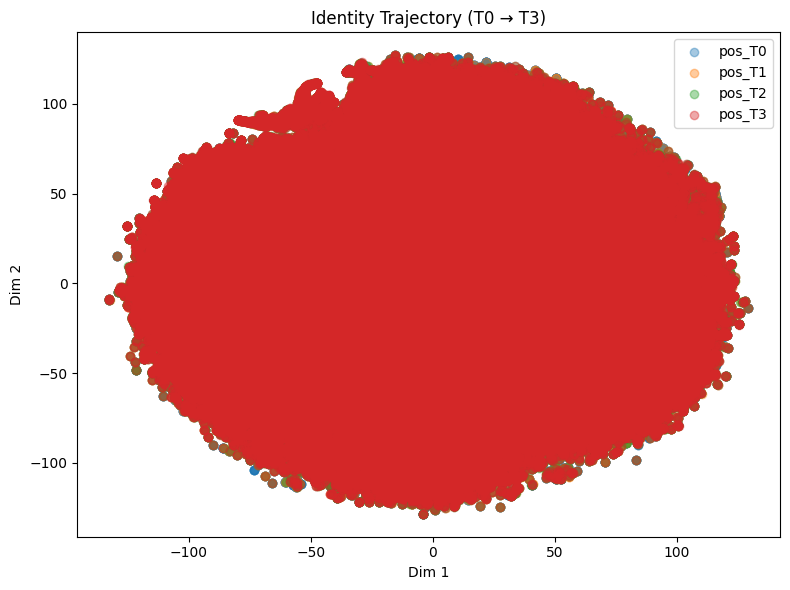

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for stage in ["pos_T0", "pos_T1", "pos_T2", "pos_T3"]:
    idx = [i for i, s in enumerate(stages) if s == stage]
    plt.scatter(
        X_embedded[idx, 0],
        X_embedded[idx, 1],
        label=stage,
        alpha=0.4
    )

plt.legend()
plt.title("Identity Trajectory (T0 → T3)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.tight_layout()
plt.show()

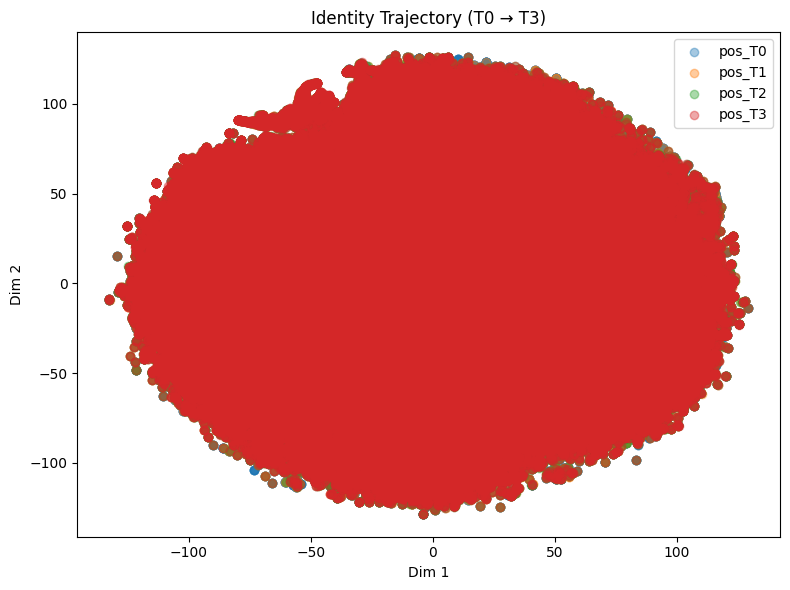

In [32]:
plt.figure(figsize=(8,6))

for stage in ["pos_T0", "pos_T1", "pos_T2", "pos_T3"]:
    idx = [i for i, s in enumerate(stages) if s == stage]
    plt.scatter(
        X_embedded[idx, 0],
        X_embedded[idx, 1],
        label=stage,
        alpha=0.4
    )

plt.legend()
plt.title("Identity Trajectory (T0 → T3)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.tight_layout()
plt.savefig(OUT_DIR / "identity_trajectory_tsne.png", dpi=300, bbox_inches="tight")
plt.show()

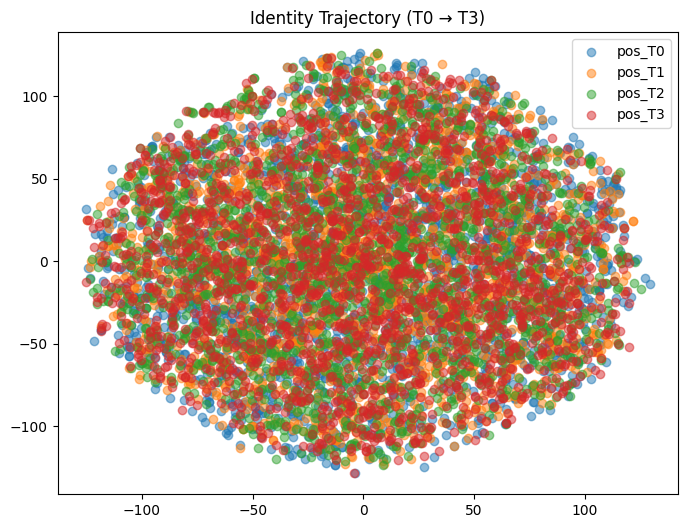

In [33]:
import random

plt.figure(figsize=(8,6))

for stage in ["pos_T0", "pos_T1", "pos_T2", "pos_T3"]:
    idx = [i for i, s in enumerate(stages) if s == stage]
    
    sample_idx = random.sample(idx, 2000)  # 👈 关键
    
    plt.scatter(
        X_embedded[sample_idx, 0],
        X_embedded[sample_idx, 1],
        label=stage,
        alpha=0.5
    )

plt.legend()
plt.title("Identity Trajectory (T0 → T3)")
plt.show()

In [35]:
import random
import matplotlib.pyplot as plt

models = [
    "chatgpt",
    "palm",
    "dipper(high)",
    "dipper(low)",
    "pegasus(slight)",
    "pegasus(full)"
]

def plot_one_model(base):
    plt.figure(figsize=(6,5))

    for stage in ["pos_T0", "pos_T1", "pos_T2", "pos_T3"]:
        idx = [
            i for i, (s, b) in enumerate(zip(stages, labels))
            if s == stage and b == base
        ]

        if len(idx) == 0:
            continue

        sample_idx = random.sample(idx, min(1000, len(idx)))

        plt.scatter(
            X_embedded[sample_idx, 0],
            X_embedded[sample_idx, 1],
            label=stage,
            alpha=0.6,
            s=12
        )

    plt.legend()
    plt.title(f"{base} (T0 → T3)")
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.tight_layout()

    plt.savefig(OUT_DIR / f"tsne_{base}.png", dpi=300, bbox_inches="tight")
    plt.show()

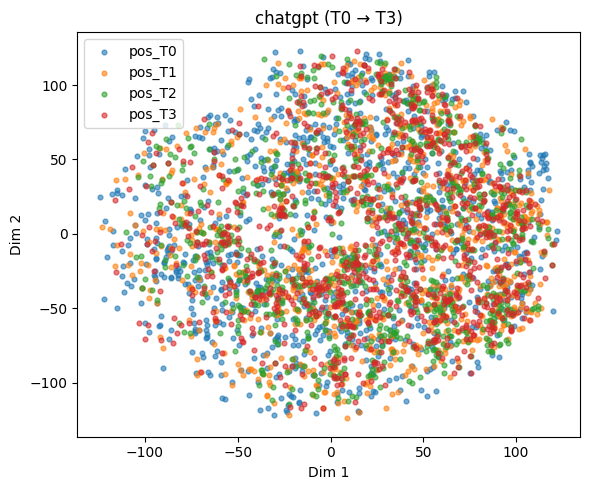

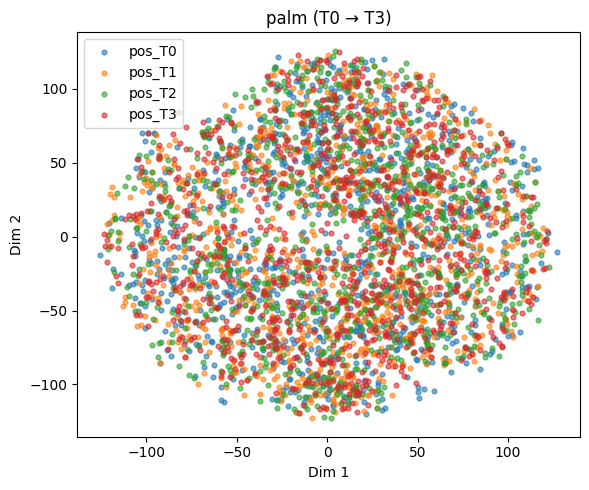

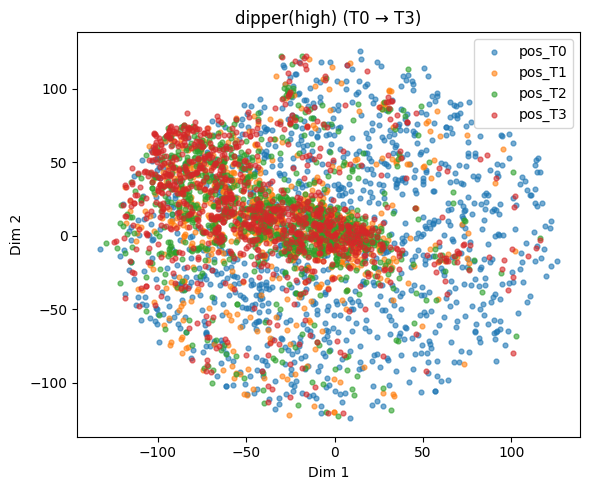

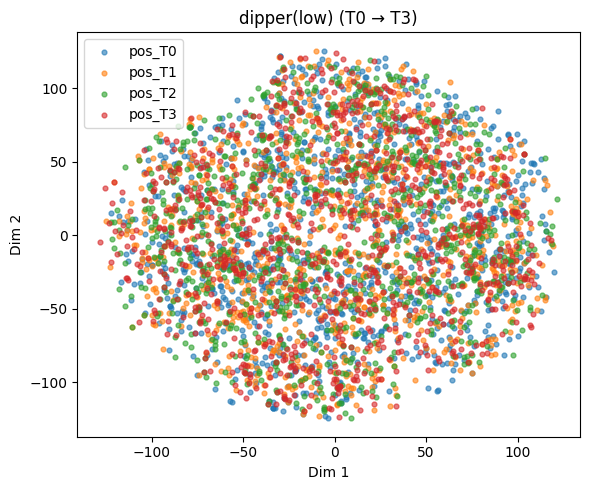

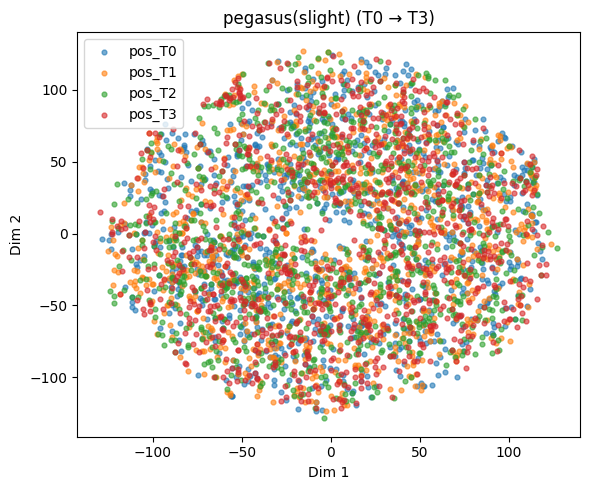

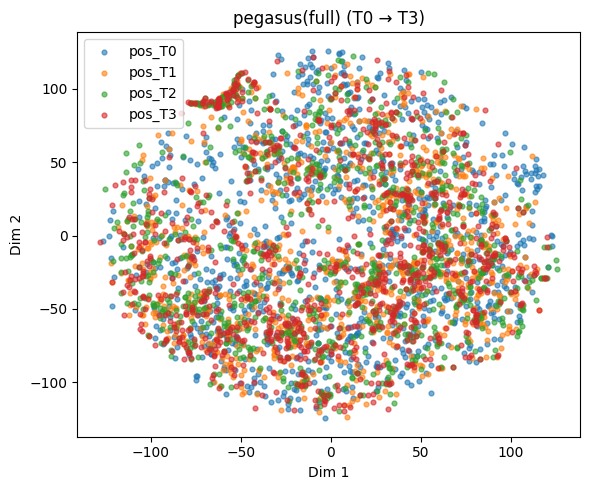

In [36]:
for m in models:
    plot_one_model(m)